## Importing  Libraries

In [15]:
import pandas as pd
import numpy as np
import json
import os
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import re

warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Importing Datasets

In [3]:
# Load modules.csv for analysis
modules_df = pd.read_csv('../data/modules.csv')

# Display basic info
print(f"Dataset shape: {modules_df.shape}")
print(f"\nColumns: {list(modules_df.columns)}")
modules_df.head()

Dataset shape: (7015, 14)

Columns: ['moduleCode', 'title', 'acadYear', 'faculty', 'department', 'moduleCredit', 'description', 'additionalInformation', 'workload', 'gradingBasisDescription', 'preclusion', 'prerequisite', 'corequisite', 'semestersOffered']


,moduleCode,title,acadYear,faculty,department,moduleCredit,description,additionalInformation,workload,gradingBasisDescription,preclusion,prerequisite,corequisite,semestersOffered
0,ABM5001,Leadership in Biomedicine,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,Leadership is fundamental to the success of in...,NaN,3/0/0/4/3,Graded,NaN,NaN,NaN,2
1,ABM5002,Advanced Biostatistics for Research,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,This course is served as a concept-based intro...,NaN,1.5/0.5/0/0/3,Graded,NaN,NaN,NaN,2
2,ABM5003,Biomedical Innovation & Enterprise,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,This course will furnish students with a thoro...,NaN,1.5/1.5/0/3/4,Graded,NaN,NaN,NaN,1
3,ABM5004,Capstone Project,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,8.0,This course encompasses research projects rele...,NaN,0/0/18/2/0,Graded,NaN,NaN,NaN,"1,2"
4,ABM5101,Applied Immunology,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,Advanced immunological applications play impor...,NaN,2/2.5/0/1/4.5,Graded,NaN,NaN,NaN,1


### EDA

#### Missing Values

In [4]:
missing = modules_df.isnull().sum().sort_values(ascending=False)
print(missing)

additionalInformation      6926
corequisite                6910
prerequisite               4046
preclusion                 3977
workload                    211
description                 147
moduleCredit                  0
department                    0
faculty                       0
acadYear                      0
title                         0
moduleCode                    0
gradingBasisDescription       0
semestersOffered              0
dtype: int64


#### Duplicate Check

In [5]:
duplicates = modules_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


#### Noise Detection

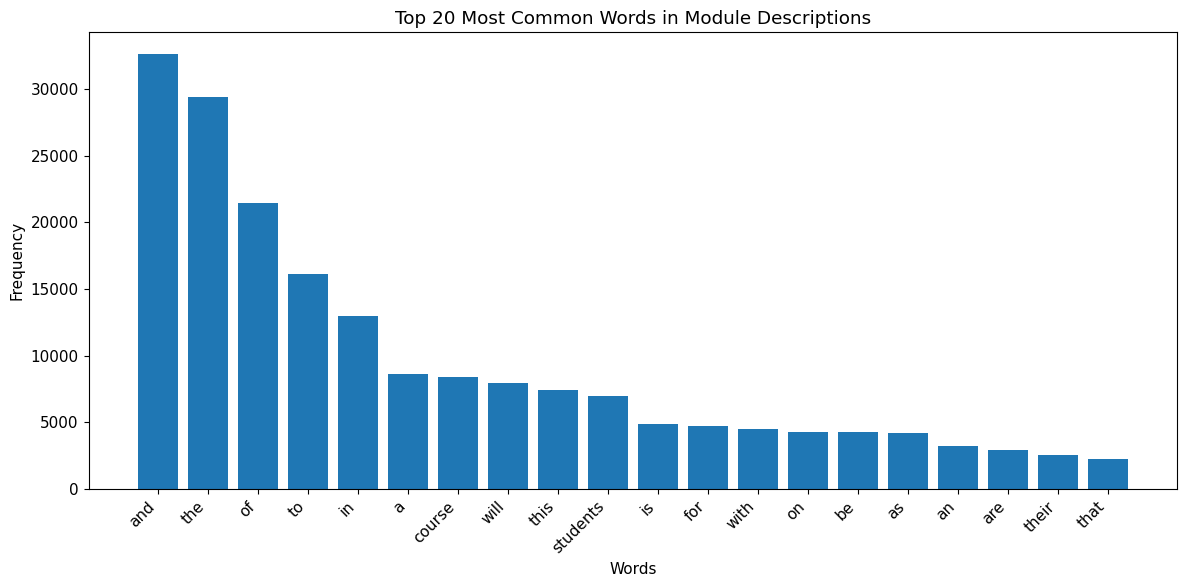

In [12]:
# combine all descriptions into one text
text = " ".join(
    modules_df["description"]
    .fillna("")
    .astype(str)
    .str.lower()
)

# split into words
words = text.split()

# count frequency
word_freq = Counter(words)

# get top 20 most common words
top_words = word_freq.most_common(20)

labels = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# plot
plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Most Common Words in Module Descriptions")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Data Preprocessing

In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)      # remove numbers
    return text

modules_df['clean_desc'] = modules_df['description'].fillna("").apply(clean_text)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(modules_df['clean_desc'])

feature_names = vectorizer.get_feature_names_out()
print(f"Top 100 features: {feature_names[:100]}")

Top 100 features: ['ability' 'able' 'academic' 'academic knowledge' 'academic science'
 'access' 'account' 'accounting' 'achieve' 'acquire' 'acquire work'
 'action' 'active' 'activities' 'actual' 'actual working' 'addition'
 'addition having' 'address' 'advanced' 'affect' 'agreed' 'agreement' 'ai'
 'aim' 'aim course' 'aimed' 'aims' 'aims equip' 'aims provide'
 'algorithms' 'allow' 'allows' 'analyse' 'analyses' 'analysing' 'analysis'
 'analytical' 'analytics' 'analyze' 'andor' 'application' 'applications'
 'applied' 'apply' 'applying' 'appreciate' 'appreciation' 'approach'
 'approaches' 'appropriate' 'approval' 'approved' 'approved topic'
 'arbitration' 'architecture' 'area' 'areas' 'art' 'artificial' 'arts'
 'asia' 'asian' 'aspects' 'assess' 'assessed' 'assessment' 'assignments'
 'assignments actual' 'associated' 'attachment' 'attachment internship'
 'attention' 'available' 'background' 'based' 'basic' 'basic concepts'
 'basic principles' 'basics' 'basis' 'behaviour' 'best' 'better'
 '

There still is a lot generic / academic words, unable to to show skills and job relevancy.

In [21]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

academic_stopwords = {
    "ability", "able", "academic", "access", "account", "achieve", "acquire",
    "action", "active", "activities", "actual", "addition", "address",
    "advanced", "affect", "agreed", "agreement", "aim", "aimed", "aims",
    "allow", "allows", "analyse", "analyses", "analysing", "analysis",
    "analytical", "analyze", "application", "applications", "applied",
    "apply", "applying", "appreciate", "appreciation", "approach",
    "approaches", "appropriate", "approval", "approved", "area", "areas",
    "aspects", "assess", "assessed", "assessment", "assignments",
    "associated", "attention", "available", "background", "based", "basic",
    "basics", "basis", "best", "better", "broad", "build", "building",
    "built", "body", "course", "courses", "concept", "concepts", "content",
    "cover", "covers", "develop", "developed", "developing", "development",
    "equip", "focus", "foundation", "introduce", "introduces", "introduction",
    "knowledge", "learn", "learning", "method", "methods", "module",
    "modules", "prepare", "prepared", "principle", "principles", "provide",
    "provides", "students", "student", "study", "topics", "understand",
    "understanding", "use", "uses", "using"
}

custom_stopwords = ENGLISH_STOP_WORDS.union(academic_stopwords)

In [22]:
corpus = modules_df["description"].fillna("").astype(str)

vectorizer = TfidfVectorizer(
    stop_words=list(custom_stopwords),
    max_features=300,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.6
)

X = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

scores = np.asarray(X.mean(axis=0)).ravel()
top_idx = scores.argsort()[-50:][::-1]

top_features = [feature_names[i] for i in top_idx]
print("Top 50 features:", top_features)

Top 50 features: ['research', 'design', 'data', 'skills', 'project', 'law', 'work', 'systems', 'include', 'social', 'issues', 'techniques', 'management', 'science', 'business', 'theory', 'health', 'major', 'various', 'including', 'singapore', 'world', 'engineering', 'problems', 'covered', 'studies', 'different', 'international', 'experience', 'related', 'practice', 'human', 'practical', 'real', 'processes', 'cultural', 'tools', 'process', 'key', 'economic', 'performance', 'models', 'used', 'internship', 'topic', 'projects', 'materials', 'political', 'designed', 'fundamental']


In [5]:
# Load data for Job Ads
# Windows add r"", Mac/Linux use ""
job_ads = r"C:\Users\matth\Downloads\problem2\data" # change to local path of data folder for job ads
print(f"📂 Reading data from: {os.path.abspath(job_ads)}")


📂 Reading data from: C:\Users\matth\Downloads\problem2\data


In [6]:
def load_jobs(folder):
    if not os.path.exists(folder):
        raise FileNotFoundError(
            f"\n❌ Folder not found: '{os.path.abspath(folder)}'\n"
            f"Please update DATA_FOLDER in the first cell to point to your local data folder."
        )
    
    jobs = []
    for filename in os.listdir(folder):
        if filename.endswith(".json"):
            filepath = os.path.join(folder, filename)
            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    jobs.append(json.load(f))
            except Exception as e:
                print(f"  ⚠️  Could not read {filename}: {e}")
    
    if not jobs:
        raise ValueError(
            f"\n❌ No .json files found in '{os.path.abspath(folder)}'\n"
            f"Make sure your JSON files are in the correct folder."
        )
    
    print(f"✅ Loaded {len(jobs)} job files successfully.")
    return jobs


def extract_fields(jobs):
    rows = []
    for job in jobs:
        title      = job.get("title", "Unknown")
        categories = [c.get("category", "") for c in job.get("categories", [])]
        skills     = [s.get("skill", "")    for s in job.get("skills", [])]
        emp_types  = [e.get("employmentType", "") for e in job.get("employmentTypes", [])]
        positions  = [p.get("position", "")       for p in job.get("positionLevels", [])]

        rows.append({
            "job_id":          job.get("metadata", {}).get("jobPostId", "N/A"),
            "title":           title,
            "company":         job.get("postedCompany", {}).get("name", "Unknown"),
            "categories":      ", ".join(categories) if categories else "Uncategorised",
            "skills":          skills,
            "skills_str":      ", ".join(skills) if skills else "None",
            "employment_type": ", ".join(emp_types),
            "position_level":  ", ".join(positions),
        })
    return pd.DataFrame(rows)


jobs = load_jobs(job_ads)
df   = extract_fields(jobs)
df.head()

✅ Loaded 22720 job files successfully.


,job_id,title,company,categories,skills,skills_str,employment_type,position_level
0,ATS-2026-0184172,"Assistant Manager, Corporate Communications",CITY DEVELOPMENTS LIMITED,Marketing / Public Relations,"[Multimedia, Social Media, Strategic Communica...","Multimedia, Social Media, Strategic Communicat...",Permanent,Junior Executive
1,ATS-2026-0190206,Manager (Facilities Management),NTUC FAIRPRICE CO-OPERATIVE LTD,Real Estate / Property Management,"[Fire Safety, Management Skills, Sustainabilit...","Fire Safety, Management Skills, Sustainability...",Permanent,Manager
2,MCF-2025-1100407,Sales Administrator,THE FULLERTON HOTEL,"Hospitality, Sales / Retail","[Sales, Microsoft Office, Microsoft Excel, Tra...","Sales, Microsoft Office, Microsoft Excel, Trav...",Full Time,Executive
3,MCF-2025-1103608,Assistant Field Engineer(Construction),"ENZAN KOUBOU CO., LTD. Singapore Branch","Customer Service, Engineering, Professional Se...","[Troubleshooting, Construction, Hardware, Elec...","Troubleshooting, Construction, Hardware, Elect...",Full Time,Fresh/entry level
4,MCF-2025-1105270,Electronic Keyboard Teacher,SYMPHONY MUSIC SCHOOL,Education and Training,"[Piano, Classical, Microsoft Excel, Teaching, ...","Piano, Classical, Microsoft Excel, Teaching, C...",Full Time,Non-executive


In [7]:
total_skills  = sum(len(s) for s in df["skills"])
unique_skills = len(set(s for lst in df["skills"] for s in lst))

summary = pd.DataFrame({
    "Metric": [
        "Total job postings",
        "Unique job titles",
        "Unique companies",
        "Unique categories",
        "Total skill tags",
        "Unique skills"
    ],
    "Value": [
        len(df),
        df["title"].nunique(),
        df["company"].nunique(),
        df["categories"].str.split(", ").explode().nunique(),
        total_skills,
        unique_skills
    ]
})
summary

,Metric,Value
0,Total job postings,22720
1,Unique job titles,14996
2,Unique companies,5377
3,Unique categories,43
4,Total skill tags,334729
5,Unique skills,9491


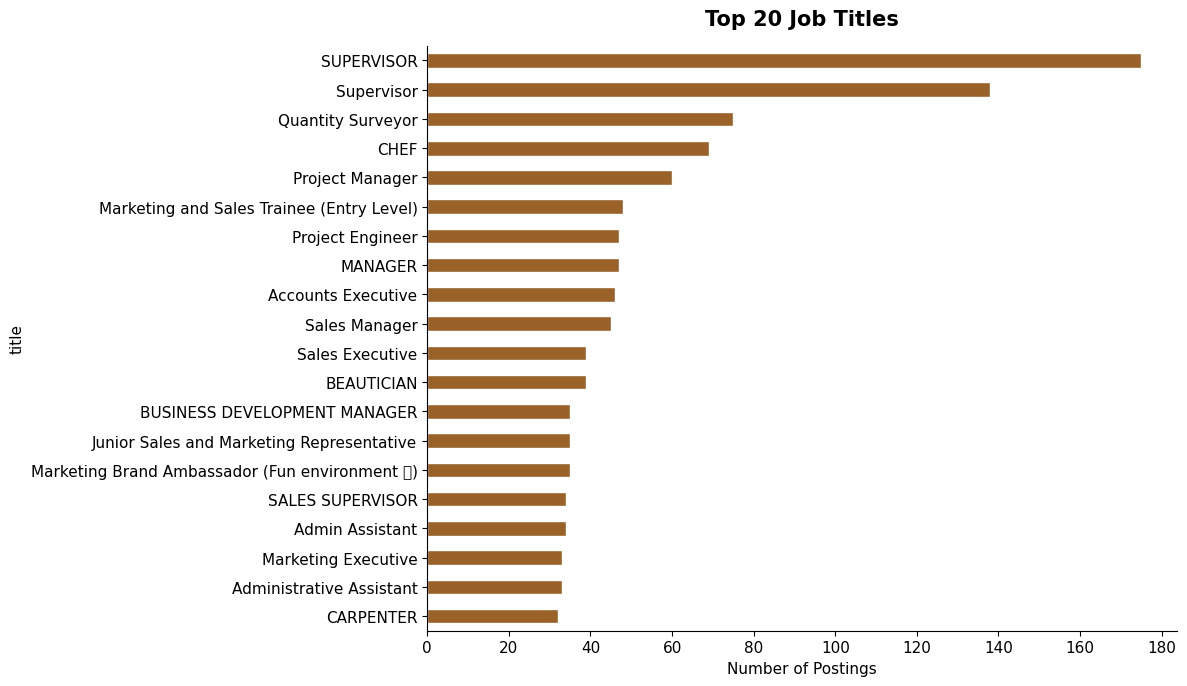


Full table:


,Count,count
0,SUPERVISOR,175
1,Supervisor,138
2,Quantity Surveyor,75
3,CHEF,69
4,Project Manager,60
5,Marketing and Sales Trainee (Entry Level),48
6,Project Engineer,47
7,MANAGER,47
8,Accounts Executive,46
9,Sales Manager,45


In [10]:
top_titles = df["title"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
top_titles.sort_values().plot(kind="barh", ax=ax, color="#9a6228", edgecolor="white")
ax.set_title("Top 20 Job Titles", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Number of Postings")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("\nFull table:")
top_titles.reset_index().rename(columns={"index": "Title", "title": "Count"})

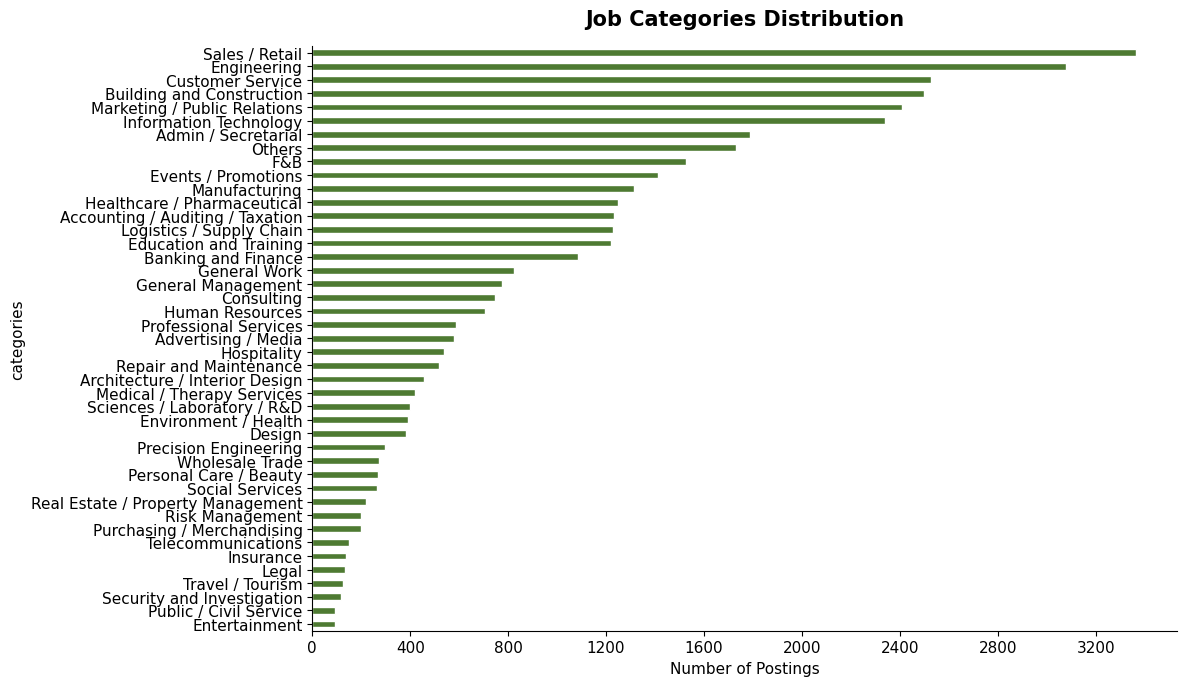

,Count,count
0,Sales / Retail,3364
1,Engineering,3079
2,Customer Service,2527
3,Building and Construction,2499
4,Marketing / Public Relations,2409
5,Information Technology,2338
6,Admin / Secretarial,1788
7,Others,1729
8,F&B,1528
9,Events / Promotions,1414


In [11]:
cat_counts = df["categories"].str.split(", ").explode().value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
cat_counts.sort_values().plot(kind="barh", ax=ax, color="#4e7a32", edgecolor="white")
ax.set_title("Job Categories Distribution", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Number of Postings")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

cat_counts.reset_index().rename(columns={"index": "Category", "categories": "Count"})

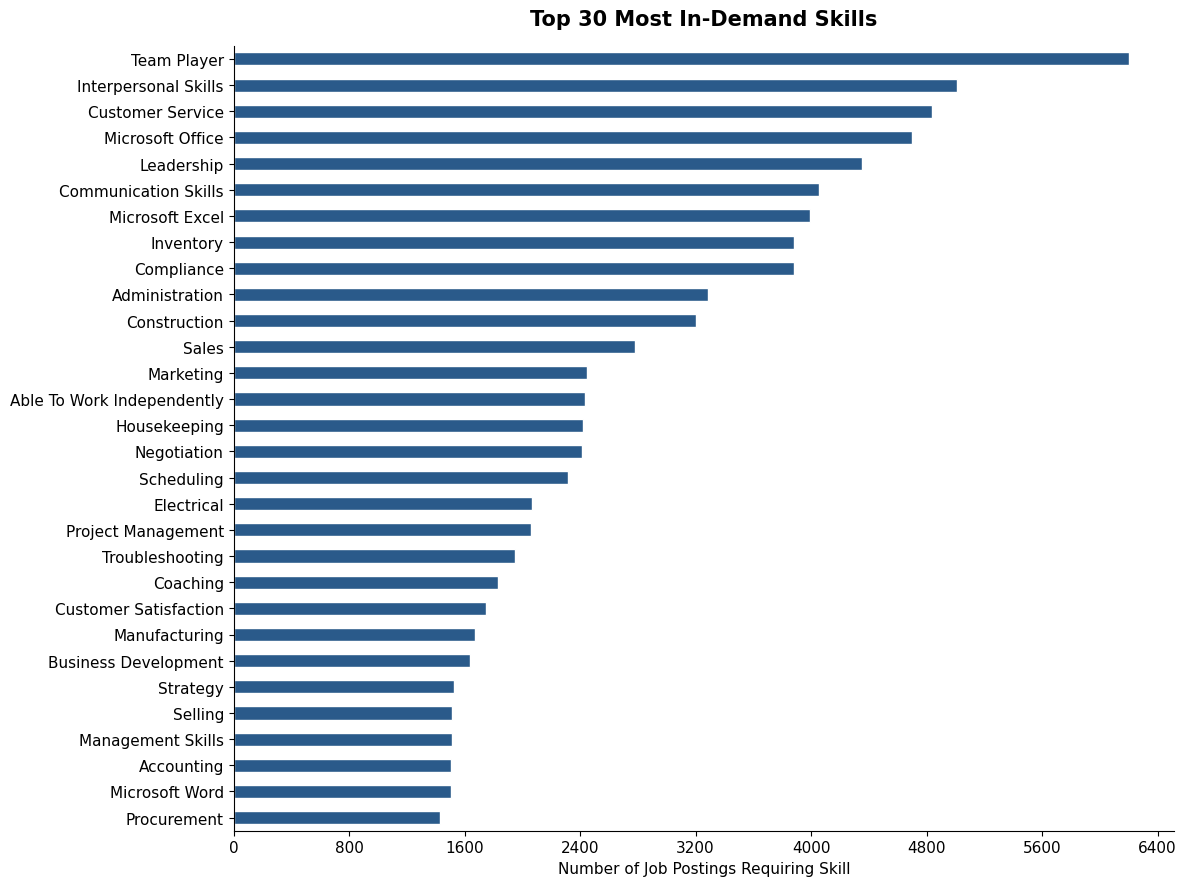

,Skill,Count
0,Team Player,6204
1,Interpersonal Skills,5011
2,Customer Service,4835
3,Microsoft Office,4699
4,Leadership,4353
5,Communication Skills,4054
6,Microsoft Excel,3991
7,Inventory,3884
8,Compliance,3882
9,Administration,3289


In [12]:
all_skills  = [s for lst in df["skills"] for s in lst]
top_skills  = pd.Series(Counter(all_skills)).nlargest(30)

fig, ax = plt.subplots(figsize=(12, 9))
top_skills.sort_values().plot(kind="barh", ax=ax, color="#2a5a8a", edgecolor="white")
ax.set_title("Top 30 Most In-Demand Skills", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Number of Job Postings Requiring Skill")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

top_skills.reset_index().rename(columns={"index": "Skill", 0: "Count"})

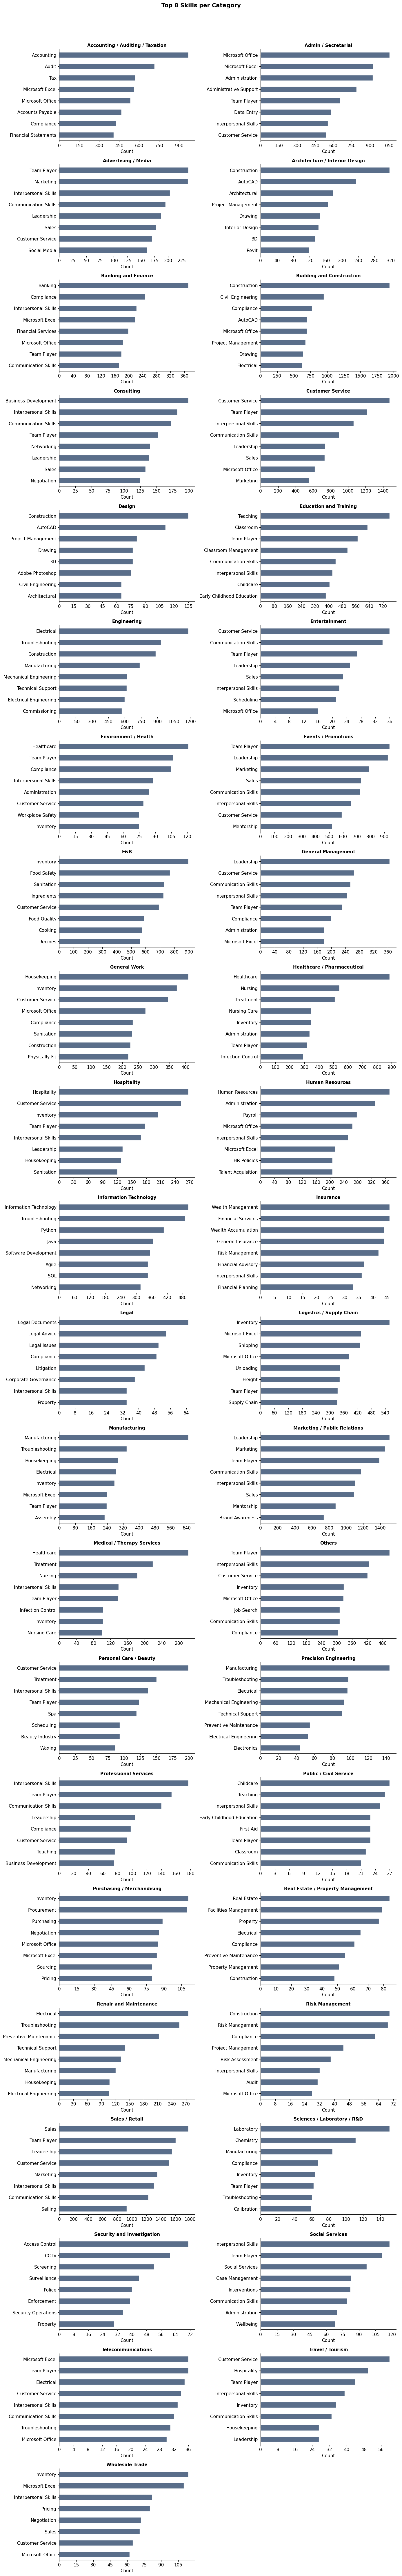

In [13]:
df_exp = df.copy()
df_exp["category_single"] = df_exp["categories"].str.split(", ")
df_exp = df_exp.explode("category_single")

categories = df_exp["category_single"].unique()
n_cols = 2
n_rows = -(-len(categories) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, cat in enumerate(sorted(categories)):
    cat_df     = df_exp[df_exp["category_single"] == cat]
    skills_flat = [s for lst in cat_df["skills"] for s in lst]
    top         = pd.Series(Counter(skills_flat)).nlargest(8)

    if not top.empty:
        top.sort_values().plot(kind="barh", ax=axes[i], color="#5a6e8a", edgecolor="white")
    axes[i].set_title(cat, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Count")
    axes[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    axes[i].spines[["top", "right"]].set_visible(False)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top 8 Skills per Category", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()